In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [9]:
df= pd.read_csv("train.csv")
df.head()

,id,qid1,qid2,question1,question2,is_duplicate
0,0,1,2,What is the step by step guide to invest in sh...,What is the step by step guide to invest in sh...,0
1,1,3,4,What is the story of Kohinoor (Koh-i-Noor) Dia...,What would happen if the Indian government sto...,0
2,2,5,6,How can I increase the speed of my internet co...,How can Internet speed be increased by hacking...,0
3,3,7,8,Why am I mentally very lonely? How can I solve...,Find the remainder when [math]23^{24}[/math] i...,0
4,4,9,10,"Which one dissolve in water quikly sugar, salt...",Which fish would survive in salt water?,0


In [10]:
df.shape

(404290, 6)

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 404290 entries, 0 to 404289
Data columns (total 6 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   id            404290 non-null  int64 
 1   qid1          404290 non-null  int64 
 2   qid2          404290 non-null  int64 
 3   question1     404289 non-null  object
 4   question2     404288 non-null  object
 5   is_duplicate  404290 non-null  int64 
dtypes: int64(4), object(2)
memory usage: 18.5+ MB


In [12]:
df.describe()

,id,qid1,qid2,is_duplicate
count,404290.000000,404290.000000,404290.000000,404290.000000
mean,202144.500000,217243.942418,220955.655337,0.369198
std,116708.614502,157751.700002,159903.182629,0.482588
min,0.000000,1.000000,2.000000,0.000000
25%,101072.250000,74437.500000,74727.000000,0.000000
50%,202144.500000,192182.000000,197052.000000,0.000000
75%,303216.750000,346573.500000,354692.500000,1.000000
max,404289.000000,537932.000000,537933.000000,1.000000


In [13]:
df.sample(10)

,id,qid1,qid2,question1,question2,is_duplicate
80745,80745,137221,137222,How do I purchase Twitter followers?,What are the best sites to buy Twitter followers?,1
105136,105136,93198,65988,Do we know if there is life on other planets?,Is there any evidence of life on other planets?,1
385883,385883,156633,245445,How is fathersrights.org making money?,How does moodle.org make money?,0
76263,76263,130396,130397,"Which is better, Surface Pro 4 or Macbook Pro ...","Should I buy a Surface Pro 4 (i5, 8GB RAM, 256...",1
389198,389198,521671,521672,My DOB in birth certificate as 1988. But in al...,How can I change my DOB in my passport which i...,1
277095,277095,109055,168325,How do I differentiate between love and infatu...,How is love different from infatuation?,1
9313,9313,18100,18101,I live in a town that's 70% black and I'm whit...,What is it like to be black in China?,0
123371,123371,163795,199482,Is it possible for 50 year old man and a 20 ye...,I am a 21 year old bisexual woman dating a bis...,0
258376,258376,373930,373931,If a merchant ship departs from India and has ...,I got a composite score of 708.5 and a percent...,0
119879,119879,194537,194538,Playing Guitar: What are they charging for Tab...,How do you play a table guitar?,0


In [15]:
df.isnull().sum()

id              0
qid1            0
qid2            0
question1       1
question2       2
is_duplicate    0
dtype: int64

In [16]:
df.duplicated().sum()

np.int64(0)

In [17]:
print(df['is_duplicate'].value_counts())
print(df['is_duplicate'].value_counts()/df['is_duplicate'].count()*100)

is_duplicate
0    255027
1    149263
Name: count, dtype: int64
is_duplicate
0    63.080215
1    36.919785
Name: count, dtype: float64


<Axes: xlabel='is_duplicate'>

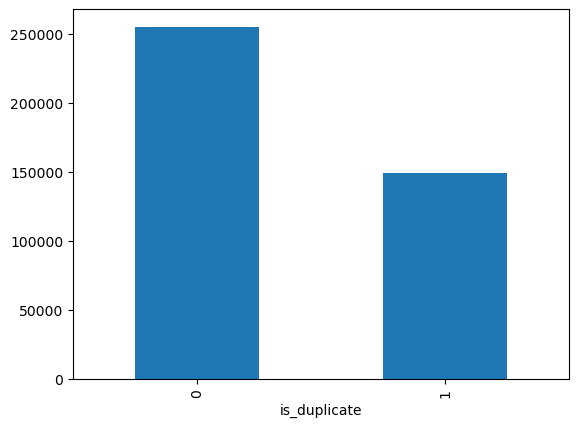

In [18]:
df['is_duplicate'].value_counts().plot(kind='bar')

In [21]:
qid= pd.Series(df['qid1'].tolist()+ df['qid2'].tolist())
print('no. of unique ques:', np.unique(qid).shape[0])
x= qid.value_counts()>1
print('no. of ques getting repeated:', x[x].shape[0])
               

no. of unique ques: 537933
no. of ques getting repeated: 111780


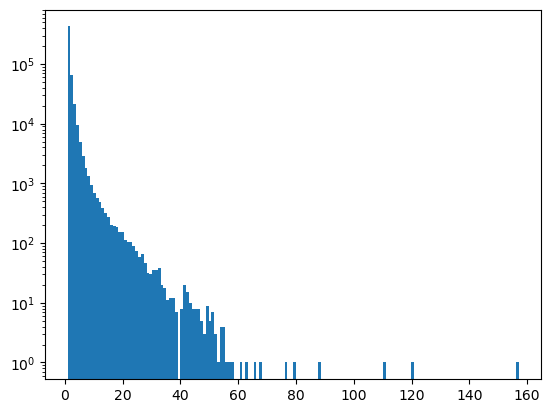

In [22]:
plt.hist(qid.value_counts().values,bins=160)
plt.yscale('log')
plt.show()

In [23]:
new_df = df.sample(30000)

In [24]:
new_df.isnull().sum()

id              0
qid1            0
qid2            0
question1       0
question2       0
is_duplicate    0
dtype: int64

In [26]:
new_df.duplicated().sum()

np.int64(0)

In [27]:
ques_df = new_df[['question1','question2']]
ques_df.head()

,question1,question2
73932,Is hookah more dangerous than cigarettes?,Does hookah cause more bodily harm than smokin...
370244,How can I improve my speaking?,How can improve my English speaking?
310239,What are some interesting areas of history tha...,What are some interesting areas of art history...
276634,What is El Niño?,What is the 'El Niño' effect?
378650,What are some companies using hadoop streaming?,What are some companies using Hadoop streaming...


In [28]:
from sklearn.feature_extraction.text import CountVectorizer
questions = list(ques_df['question1'])+ list(ques_df['question2'])

cv= CountVectorizer(max_features= 3000)
q1_arr, q2_arr= np.vsplit(cv.fit_transform(questions).toarray(),2)

In [30]:
temp_df1= pd.DataFrame(q1_arr, index=ques_df.index)
temp_df2= pd.DataFrame(q2_arr, index=ques_df.index)
temp_df= pd.concat([temp_df1,temp_df2],axis=1)
temp_df.shape

(30000, 6000)

In [31]:
temp_df

,0,1,2,3,4,5,6,7,8,9,...,2990,2991,2992,2993,2994,2995,2996,2997,2998,2999
73932,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
370244,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
310239,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
276634,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
378650,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
375813,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
115145,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
272794,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
326899,0,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [32]:
temp_df['is_duplicate']= new_df['is_duplicate']

In [33]:
temp_df

,0,1,2,3,4,5,6,7,8,9,...,2991,2992,2993,2994,2995,2996,2997,2998,2999,is_duplicate
73932,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
370244,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
310239,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
276634,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
378650,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
375813,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
115145,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
272794,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
326899,0,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1


In [34]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(temp_df.iloc[:,0:-1].values,temp_df.iloc[:,-1].values,test_size= 0.2,random_state=42)

In [35]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
rf = RandomForestClassifier()
rf.fit(X_train,y_train)
y_pred= rf.predict(X_test)
accuracy_score(y_test,y_pred)

0.7485

In [37]:
!pip install xgboost

   ---------------------------------------- 0.0/69.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/69.5 MB ? eta -:--:--
   ---------------------------------------- 0.3/69.5 MB ? eta -:--:--
   ---------------------------------------- 0.5/69.5 MB 1.4 MB/s eta 0:00:49
   ---------------------------------------- 0.8/69.5 MB 1.2 MB/s eta 0:00:59
    --------------------------------------- 1.3/69.5 MB 1.4 MB/s eta 0:00:49
   - -------------------------------------- 1.8/69.5 MB 1.6 MB/s eta 0:00:42
   - -------------------------------------- 2.4/69.5 MB 1.9 MB/s eta 0:00:36
   - -------------------------------------- 2.6/69.5 MB 1.7 MB/s eta 0:00:39
   - -------------------------------------- 3.1/69.5 MB 1.8 MB/s eta 0:00:37
   -- ------------------------------------- 4.2/69.5 MB 2.2 MB/s eta 0:00:31
   -- ------------------------------------- 5.0/69.5 MB 2.4 MB/s eta 0:00:28
   --- ------------------------------------ 6.0/69.5 MB 2.6 MB/s eta 0:00:25
   ---- ------------

In [41]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score

xgb = XGBClassifier()
xgb.fit(X_train, y_train)
y_pred= xgb.predict(X_test)
accuracy_score(y_test,y_pred)

0.728